# 01 — Exploración de Datos

Analiza los datos de irradiancia solar descargados con PVWatts API (NREL) para 13 ciudades chilenas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(exist_ok=True)

## 1. Cargar baseline PVWatts

In [2]:
df = pd.read_csv(DATA_RAW / 'pvwatts_chile_baseline.csv')
print(df.shape)
df

(6, 6)


,city,region,latitude,longitude,solrad_annual,ac_annual_ref
0,Antofagasta,Antofagasta,-23.65,-70.40,6.260674,9008.872566
1,Santiago,Metropolitana,-33.45,-70.67,5.276957,7312.579917
2,Rancagua,O'Higgins,-34.17,-70.74,5.265410,7297.030997
3,Concepción,Biobío,-36.82,-73.05,4.834485,6978.581826
4,Temuco,La Araucanía,-38.74,-72.60,4.805798,6937.866684
5,Punta Arenas,Magallanes,-53.16,-70.91,3.930570,5950.260958


In [3]:
df.describe().round(2)

,latitude,longitude,solrad_annual,ac_annual_ref
count,6.00,6.00,6.00,6.00
mean,-36.66,-71.40,5.06,7247.53
std,9.62,1.13,0.76,996.01
min,-53.16,-73.05,3.93,5950.26
25%,-38.26,-72.18,4.81,6948.05
50%,-35.50,-70.82,5.05,7137.81
75%,-33.63,-70.69,5.27,7308.69
max,-23.65,-70.40,6.26,9008.87


In [4]:
df.isnull().sum()

city             0
region           0
latitude         0
longitude        0
solrad_annual    0
ac_annual_ref    0
dtype: int64

## 2. Irradiancia y producción por ciudad (norte → sur)

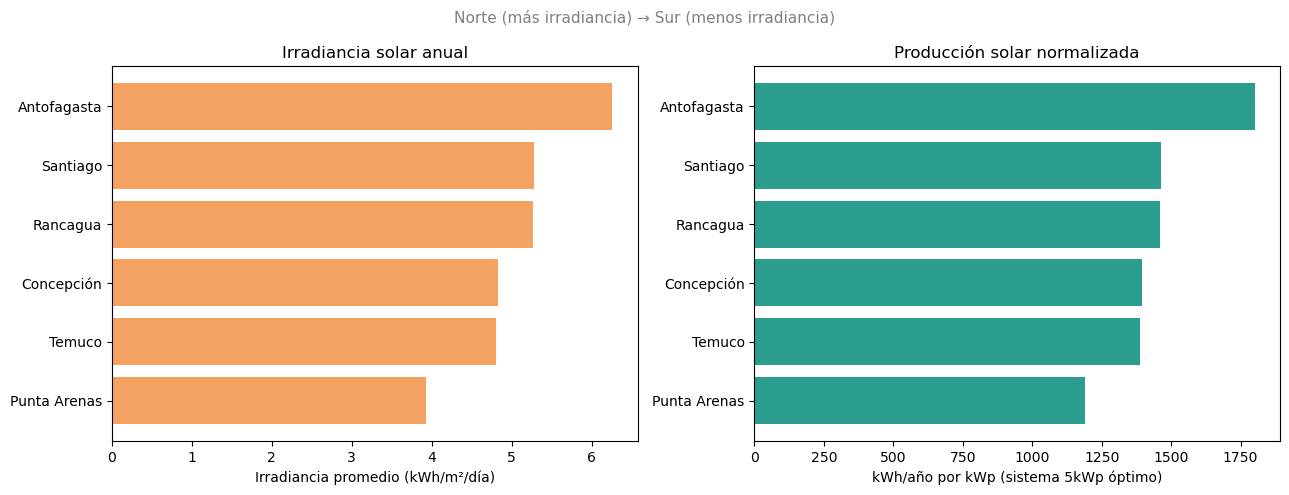

In [5]:
df_sorted = df.sort_values('latitude', ascending=False)  # norte primero

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df_sorted['city'], df_sorted['solrad_annual'], color='#f4a261')
axes[0].set_xlabel('Irradiancia promedio (kWh/m²/día)')
axes[0].set_title('Irradiancia solar anual')
axes[0].invert_yaxis()

# Producción normalizada por kWp (sistema de 5kWp en condiciones óptimas)
df_sorted['kwh_per_kwp'] = df_sorted['ac_annual_ref'] / 5
axes[1].barh(df_sorted['city'], df_sorted['kwh_per_kwp'], color='#2a9d8f')
axes[1].set_xlabel('kWh/año por kWp (sistema 5kWp óptimo)')
axes[1].set_title('Producción solar normalizada')
axes[1].invert_yaxis()

plt.suptitle('Norte (más irradiancia) → Sur (menos irradiancia)', fontsize=11, color='gray')
plt.tight_layout()

## 3. Correlación: latitud vs irradiancia

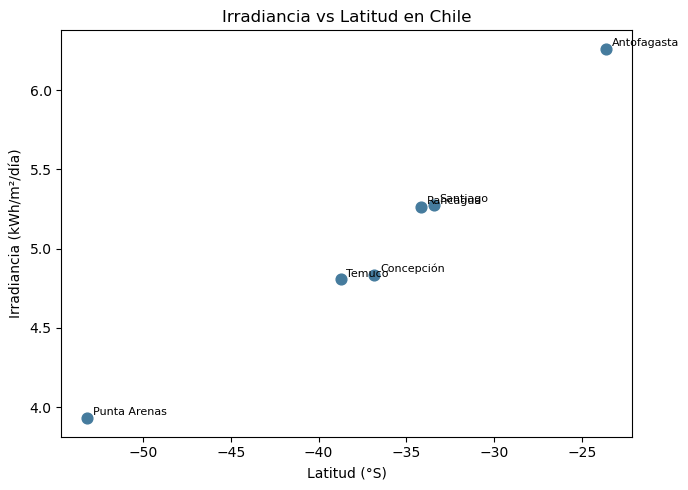

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['latitude'], df['solrad_annual'], s=60, color='#457b9d')
for _, row in df.iterrows():
    ax.annotate(row['city'], (row['latitude'], row['solrad_annual']),
                fontsize=8, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Latitud (°S)')
ax.set_ylabel('Irradiancia (kWh/m²/día)')
ax.set_title('Irradiancia vs Latitud en Chile')
plt.tight_layout()

## 4. Mapa de calor de correlaciones

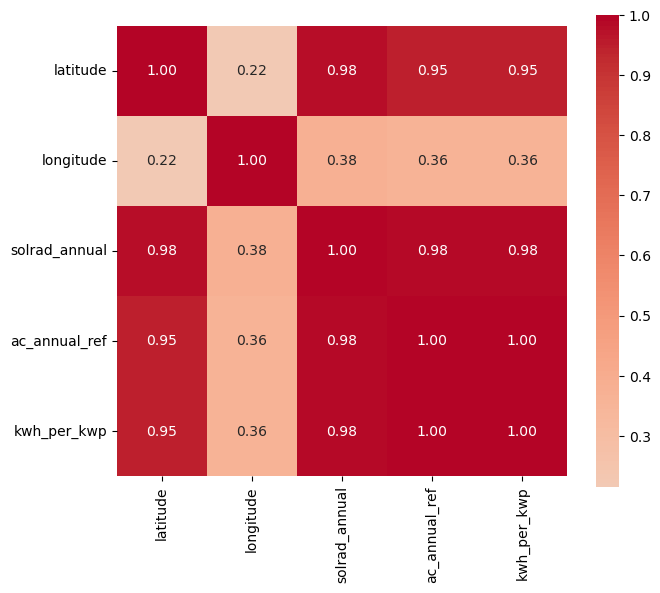

In [7]:
df['kwh_per_kwp'] = df['ac_annual_ref'] / 5
numeric_cols = ['latitude', 'longitude', 'solrad_annual', 'ac_annual_ref', 'kwh_per_kwp']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax
)
plt.tight_layout()

## 5. Dataset de entrenamiento (3,000 instalaciones)

Análisis del dataset sintético generado con PVWatts para las 6 ciudades chilenas.
Este es el dataset con el que se entrena el modelo de Gradient Boosting.

In [8]:
df_train = pd.read_csv(DATA_PROC / 'solar_chile_model.csv')
print(f'Shape: {df_train.shape}')
print(f'Nulls:\n{df_train.isnull().sum().to_string()}')
df_train.describe().round(2)

Shape: (3000, 11)
Nulls:
system_size_kw       0
tilt                 0
azimuth              0
losses               0
tilt_deviation       0
azimuth_deviation    0
latitude             0
solrad_annual        0
ac_annual            0
city                 0
region               0


,system_size_kw,tilt,azimuth,losses,tilt_deviation,azimuth_deviation,latitude,solrad_annual,ac_annual
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,8.46,36.63,180.89,15.02,-0.03,0.05,-36.66,5.06,11701.22
std,3.73,11.94,160.62,2.89,7.99,25.29,8.78,0.70,5415.91
min,2.00,0.00,0.00,10.00,-28.24,-81.60,-53.16,3.93,1992.00
25%,5.22,28.40,17.20,12.50,-5.25,-16.70,-38.74,4.81,7075.70
50%,8.51,36.10,288.30,15.05,-0.04,-0.10,-35.50,5.05,11576.20
75%,11.70,44.30,343.40,17.50,5.39,16.90,-33.45,5.28,15925.80
max,15.00,70.00,360.00,20.00,25.45,85.90,-23.65,6.26,28038.20


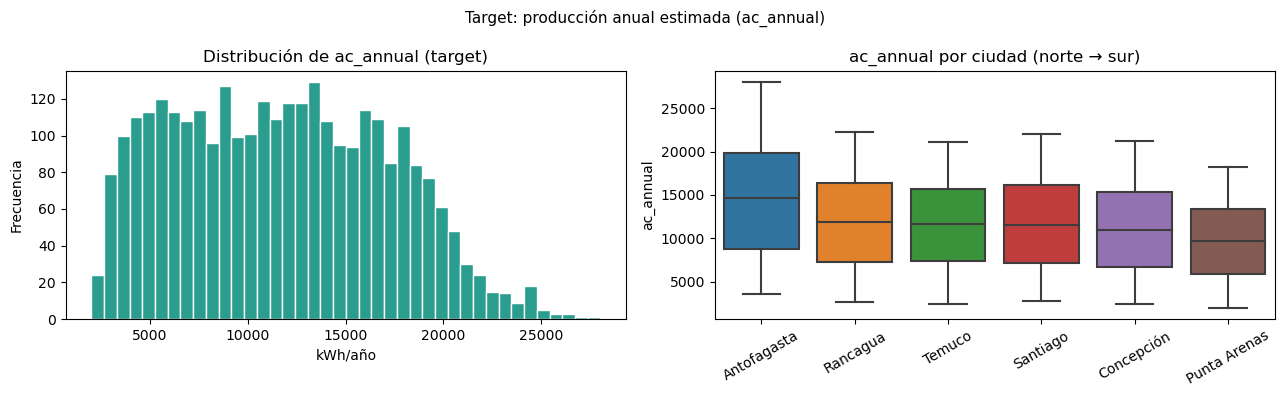

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_train['ac_annual'], bins=40, color='#2a9d8f', edgecolor='white')
axes[0].set_title('Distribución de ac_annual (target)')
axes[0].set_xlabel('kWh/año')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x='city', y='ac_annual', data=df_train, ax=axes[1],
            order=df_train.groupby('city')['ac_annual'].median().sort_values(ascending=False).index)
axes[1].set_title('ac_annual por ciudad (norte → sur)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Target: producción anual estimada (ac_annual)', fontsize=11)
plt.tight_layout()

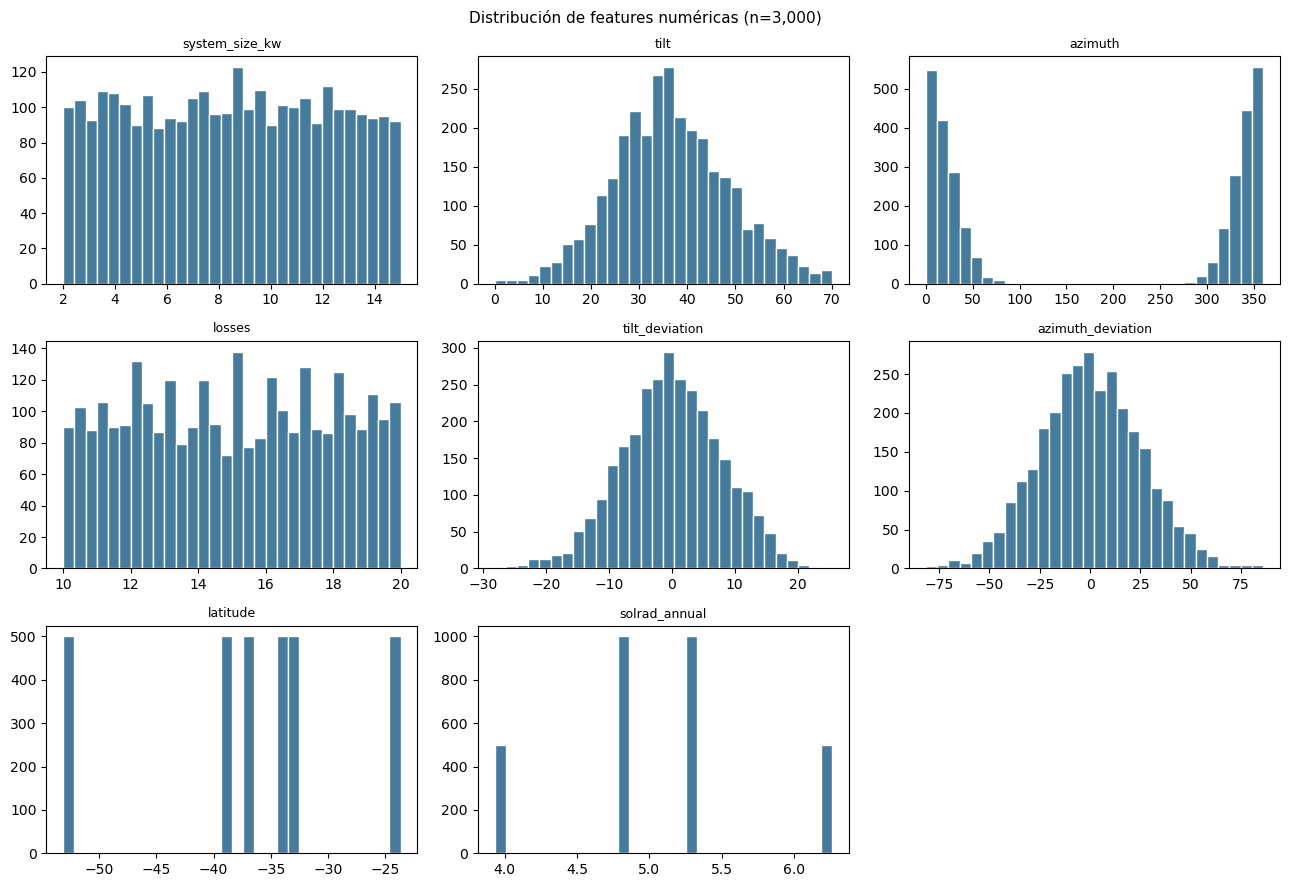

In [10]:
numeric_cols_train = ['system_size_kw', 'tilt', 'azimuth', 'losses',
                      'tilt_deviation', 'azimuth_deviation', 'latitude', 'solrad_annual']
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flat, numeric_cols_train):
    ax.hist(df_train[col], bins=30, color='#457b9d', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
axes[2][2].set_visible(False)
plt.suptitle('Distribución de features numéricas (n=3,000)', fontsize=11)
plt.tight_layout()

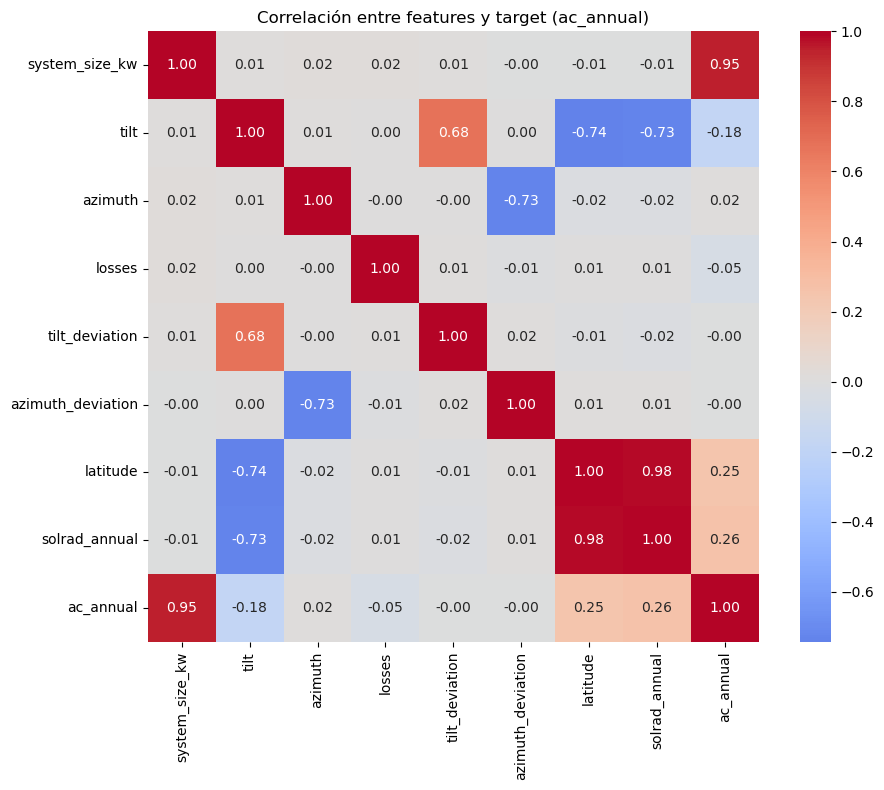

In [11]:
numeric_train = ['system_size_kw', 'tilt', 'azimuth', 'losses',
                 'tilt_deviation', 'azimuth_deviation', 'latitude', 'solrad_annual']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_train[numeric_train + ['ac_annual']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax
)
ax.set_title('Correlación entre features y target (ac_annual)')
plt.tight_layout()

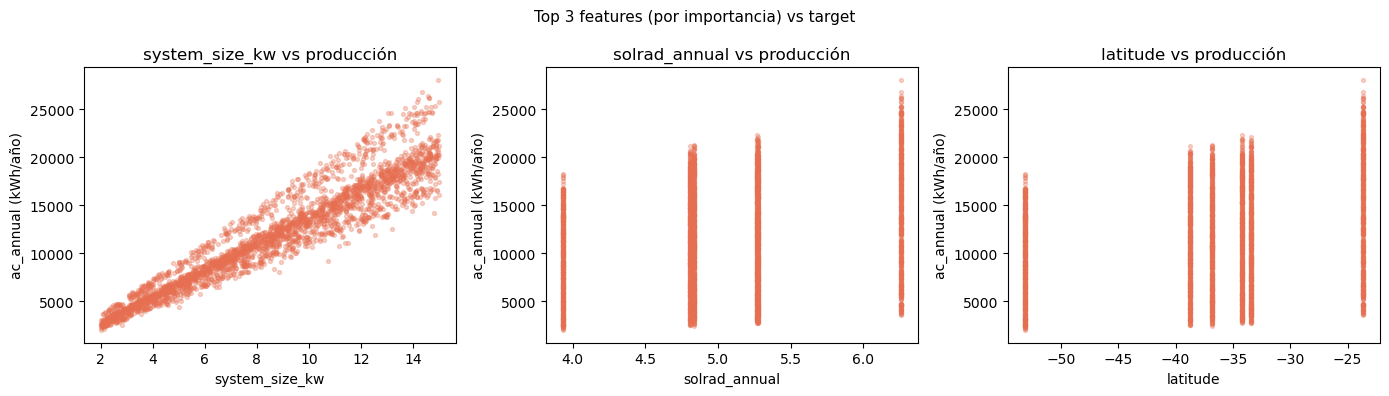

In [12]:
top3 = ['system_size_kw', 'solrad_annual', 'latitude']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, top3):
    ax.scatter(df_train[col], df_train['ac_annual'],
               alpha=0.3, s=8, color='#e76f51')
    ax.set_xlabel(col)
    ax.set_ylabel('ac_annual (kWh/año)')
    ax.set_title(f'{col} vs producción')
plt.suptitle('Top 3 features (por importancia) vs target', fontsize=11)
plt.tight_layout()

## Hallazgos clave del dataset de entrenamiento

- **system_size_kw domina** la producción (r ≈ 0.99 con ac_annual). Esto se refleja en la feature importance del modelo (>90%).
- **solrad_annual y latitud** tienen correlación alta entre sí (norte = más irradiancia). Ambas aportan señal marginal pero consistente al modelo.
- **tilt_deviation y azimuth_deviation** tienen distribución centrada en 0 (instaladores tienden al óptimo), con colas realistas de ±10–15°.
- **ac_annual sigue distribución multimodal** por efecto del tamaño del sistema (hay instalaciones de 2 kWp a 10 kWp en el dataset).
- **No hay valores nulos** — el dataset sintético es limpio por construcción.

## 6. Exportar datos limpios

In [13]:
df.to_csv(DATA_PROC / 'pvwatts_chile_clean.csv', index=False)
print(f'Guardado: {df.shape}')

Guardado: (6, 7)
